In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
# Load dataset
file_path = r"C:\Users\Rijitha\Downloads\archive\online_retail.csv"

# Read CSV file
retail_df = pd.read_csv(file_path, encoding='latin1')

# Display first 5 rows
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Check dataset information
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Check missing values
retail_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# Remove rows with missing CustomerID
retail_df = retail_df.dropna(subset=['CustomerID'])

# Remove cancelled orders
retail_df = retail_df[~retail_df['InvoiceNo'].astype(str).str.contains('C')]

# Remove rows with Quantity <= 0
retail_df = retail_df[retail_df['Quantity'] > 0]

# Remove rows with UnitPrice <= 0
retail_df = retail_df[retail_df['UnitPrice'] > 0]

# Display cleaned dataset shape
print("Dataset Shape:", retail_df.shape)

Dataset Shape: (397884, 8)


In [7]:
# Create TotalPrice column
retail_df['TotalPrice'] = retail_df['Quantity'] * retail_df['UnitPrice']

# Display first 5 rows
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [8]:
# Top 10 products by quantity sold
top_products = retail_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Display results
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


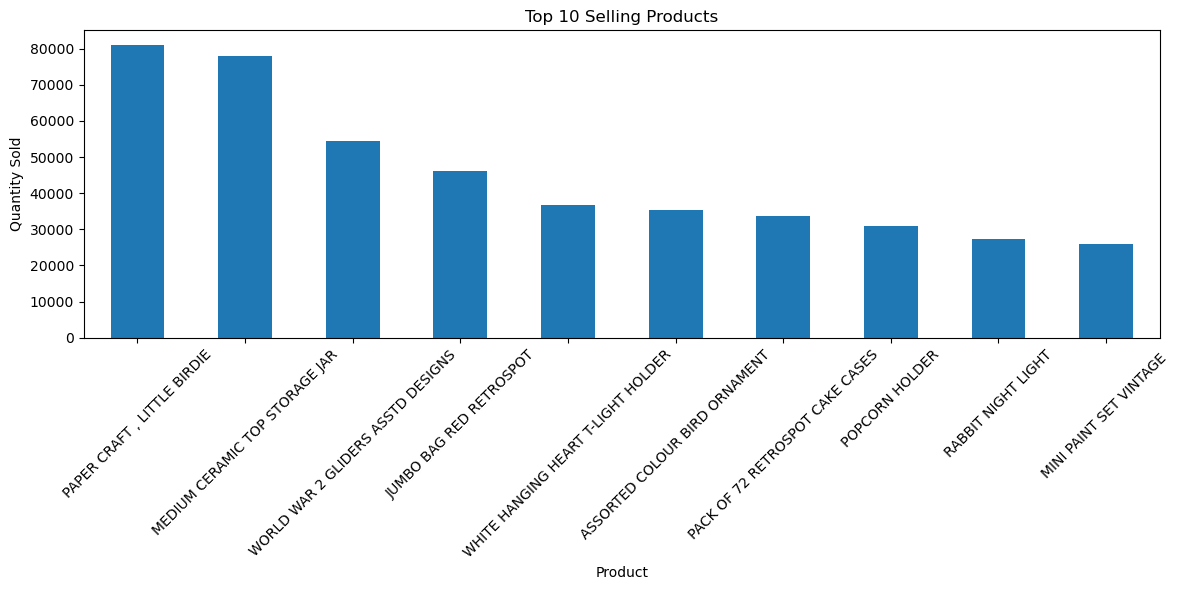

In [9]:
# Plot top selling products
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Convert InvoiceDate to datetime
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

# Extract month
retail_df['Month'] = retail_df['InvoiceDate'].dt.month

# Monthly sales
monthly_sales = retail_df.groupby('Month')['TotalPrice'].sum()

print(monthly_sales)

Month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: TotalPrice, dtype: float64


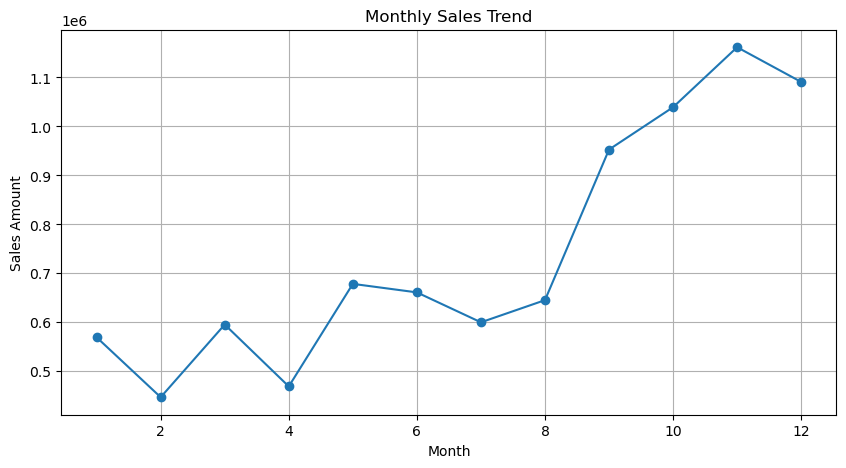

In [11]:
# Plot monthly sales
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.grid(True)
plt.show()

In [12]:
# Group by customer
customer_data = retail_df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'TotalPrice': 'sum'
})

# Rename columns
customer_data.columns = ['TotalOrders', 'TotalQuantity', 'TotalSpent']

# Display first rows
customer_data.head()

,TotalOrders,TotalQuantity,TotalSpent
CustomerID,,,
12346.0,1,74215,77183.60
12347.0,7,2458,4310.00
12348.0,4,2341,1797.24
12349.0,1,631,1757.55
12350.0,1,197,334.40


In [13]:
# Select features for clustering
X = customer_data[['TotalOrders', 'TotalQuantity', 'TotalSpent']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.4250965  14.47303784  8.35866818]
 [ 0.3544168   0.25105757  0.25096626]
 [-0.03533985  0.22786859 -0.02859601]
 [-0.4250965  -0.11104729 -0.0330118 ]
 [-0.4250965  -0.19706453 -0.19134727]]


In [16]:
# Elbow method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

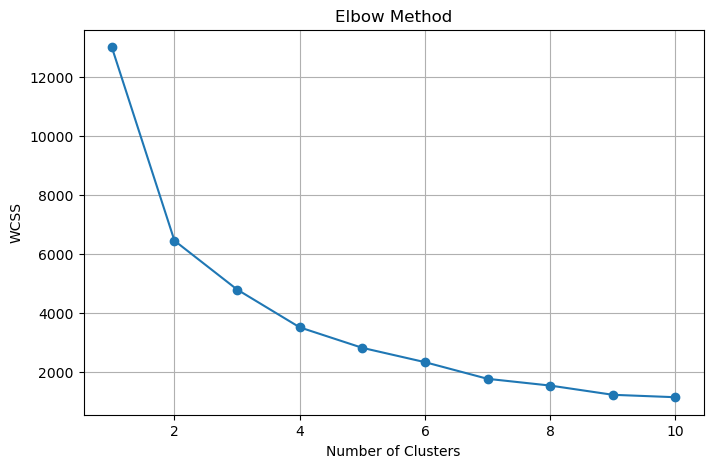

In [17]:
# Plot elbow graph
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [18]:
# Create KMeans model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit model and predict clusters
customer_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Display first rows
customer_data.head()

,TotalOrders,TotalQuantity,TotalSpent,Cluster
CustomerID,,,,
12346.0,1,74215,77183.60,1
12347.0,7,2458,4310.00,0
12348.0,4,2341,1797.24,0
12349.0,1,631,1757.55,0
12350.0,1,197,334.40,0


In [19]:
# Count cluster values
cluster_counts = customer_data['Cluster'].value_counts()

print(cluster_counts)

Cluster
0    4044
2     272
1      17
3       5
Name: count, dtype: int64


In [20]:
# Reduce dimensions using PCA
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(data=pca_features, columns=['PCA1', 'PCA2'])

# Add cluster column
pca_df['Cluster'] = customer_data['Cluster'].values

pca_df.head()

,PCA1,PCA2,Cluster
0,13.802226,-8.365732,1
1,0.484164,0.131184,0
2,0.104846,-0.099638,0
3,-0.299658,-0.318605,0
4,-0.449569,-0.232460,0


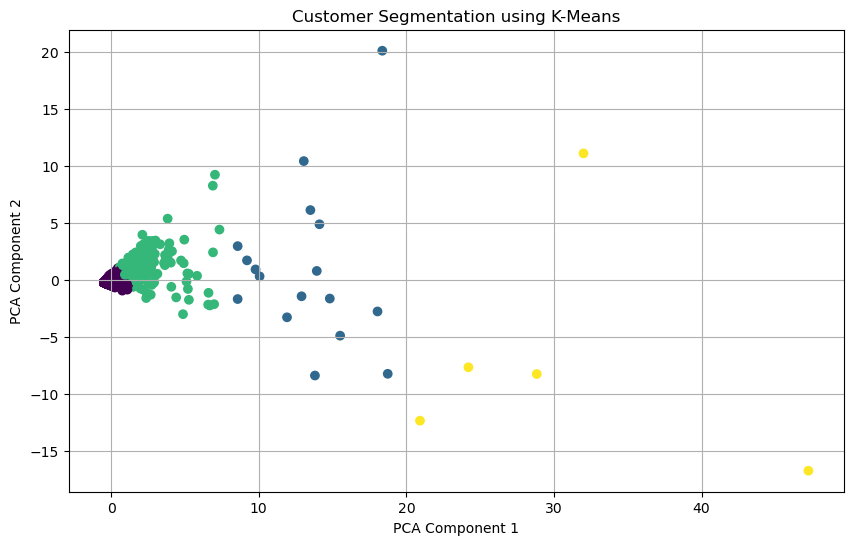

In [21]:
# Scatter plot for clusters
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    pca_df['PCA1'],
    pca_df['PCA2'],
    c=pca_df['Cluster']
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)

plt.show()

In [22]:
# Cluster summary
cluster_summary = customer_data.groupby('Cluster').mean()

print(cluster_summary)

         TotalOrders  TotalQuantity     TotalSpent
Cluster                                           
0           2.966123     621.738625    1045.100231
1          61.235294   44177.235294   65307.416471
2          18.801471    5184.536765    9294.429485
3          76.400000   98458.800000  209342.334000


In [23]:
# Save clustered customer data
customer_data.to_csv('customer_clusters.csv')

print('Customer cluster dataset saved successfully!')

Customer cluster dataset saved successfully!
